In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

FINAL_OUTPUT_PATH = "pilot_llm_output.csv"
JSONL_LOG_PATH = "pilot_api_log.jsonl"
FIG_PATH = os.path.join("..", "figures", "fig1_distribution.png")

df_output = pd.read_csv(FINAL_OUTPUT_PATH)
print(f"Loaded {len(df_output)} pilot rows.")
df_output.head()

Loaded 20 pilot rows.


,id,domain,text,llm_output,response_id,status,cumulative_cost_usd
0,385,Marketing Operations Platform,"PB - As a User, I want to re-order pages withi...",Scenario: Re-order pages within the same paren...,chatcmpl-DvbAhtY5G4qTyVVlV8W34RiE9eUUS,success,0.023145
1,210,Brand Management,"PB - As a User, I want to see a new landing page",Scenario: User views the new landing page \r\...,chatcmpl-DvbAj7hqXWd3vmaBEUKuL2XDQxZkf,success,0.023145
2,335,Marketing Operations Platform,"PB - As a User, I want to create a Drag & Drop...",Scenario: User creates a Drag & Drop Page from...,chatcmpl-DvbAkNOIt4VkPGauZMSdlhvzKEuC9,success,0.023145
3,208,Brand Management,"PB - As a User, I want to only select & see th...",Scenario: User selects and views a combo of Wi...,chatcmpl-DvbAlJKxNVm6IZebURZFXazI8uUxS,success,0.023145
4,254,Brand Management,"As a User, I want to access Reply action for N...",Scenario: Access Reply Action for New Replies ...,chatcmpl-DvbAnkVqGCgWcgix8mVVO2ltrPT4V,success,0.023145


In [ ]:
total_rows = len(df_output)
invalid_rows = df_output[df_output["status"] == "INVALID"] if "status" in df_output.columns else pd.DataFrame()
invalid_count = len(invalid_rows)
invalid_ratio = invalid_count / total_rows if total_rows > 0 else 0
print(f"INVALID: {invalid_count}/{total_rows} ({invalid_ratio:.2%})")

In [ ]:
log_records = []
if os.path.exists(JSONL_LOG_PATH):
    with open(JSONL_LOG_PATH, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                log_records.append(json.loads(line))

df_logs = pd.DataFrame(log_records) if log_records else pd.DataFrame()
total_cost = df_logs["cost_usd"].sum() if "cost_usd" in df_logs.columns else 0.0
avg_latency = df_logs["latency_sec"].mean() if "latency_sec" in df_logs.columns else np.nan
print(f"Cost: ${total_cost:.6f} USD | Avg latency: {avg_latency:.2f}s")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300)
if not df_logs.empty and "latency_sec" in df_logs.columns:
    sns.histplot(data=df_logs, x="latency_sec", kde=True, ax=axes[0], color="teal", bins=15)
if "status" in df_output.columns:
    sns.countplot(data=df_output, x="status", ax=axes[1], palette="Set2")
plt.tight_layout()
os.makedirs(os.path.dirname(FIG_PATH), exist_ok=True)
plt.savefig(FIG_PATH, bbox_inches="tight")
print("Saved", FIG_PATH)
plt.show()

In [ ]:
## 7.3 Pilot Analysis – MS


In [2]:
GROUND_TRUTH_PATH = "../data/pilot_ground_truth.csv"

df_gt = pd.read_csv(GROUND_TRUTH_PATH)

print(f"Loaded {len(df_gt)} ground truth rows")
display(df_gt.head())
print(df_gt.columns.tolist())

Loaded 20 ground truth rows


,ID,domain,User Story,Manual Scenario
0,385,Marketing Operations Platform,"PB - As a User, I want to re-order pages withi...",Scenario: Reordering Pages and Sub-Pages via D...
1,210,Brand Management,"PB - As a User, I want to see a new landing page",Scenario: User views a new landing page with e...
2,335,Marketing Operations Platform,"PB - As a User, I want to create a Drag & Drop...",Scenario: Creating a Drag & Drop Page from Nav...
3,208,Brand Management,"PB - As a User, I want to only select & see th...",Scenario: User selects a Widget and Block as a...
4,254,Brand Management,"As a User, I want to access Reply action for N...",Scenario: User can access and reply to new com...


['ID', 'domain', 'User Story', 'Manual Scenario']


In [3]:
# Merge LLM output với Ground Truth

df_output["id"] = df_output["id"].astype(str)
df_gt["ID"] = df_gt["ID"].astype(str)

df = df_output.merge(
    df_gt,
    left_on="id",
    right_on="ID",
    how="inner"
)

print(f"Merged rows: {len(df)}")

display(
    df[[
        "id",
        "text",
        "User Story",
        "llm_output",
        "Manual Scenario"
    ]].head()
)

Merged rows: 20


,id,text,User Story,llm_output,Manual Scenario
0,385,"PB - As a User, I want to re-order pages withi...","PB - As a User, I want to re-order pages withi...",Scenario: Re-order pages within the same paren...,Scenario: Reordering Pages and Sub-Pages via D...
1,210,"PB - As a User, I want to see a new landing page","PB - As a User, I want to see a new landing page",Scenario: User views the new landing page \r\...,Scenario: User views a new landing page with e...
2,335,"PB - As a User, I want to create a Drag & Drop...","PB - As a User, I want to create a Drag & Drop...",Scenario: User creates a Drag & Drop Page from...,Scenario: Creating a Drag & Drop Page from Nav...
3,208,"PB - As a User, I want to only select & see th...","PB - As a User, I want to only select & see th...",Scenario: User selects and views a combo of Wi...,Scenario: User selects a Widget and Block as a...
4,254,"As a User, I want to access Reply action for N...","As a User, I want to access Reply action for N...",Scenario: Access Reply Action for New Replies ...,Scenario: User can access and reply to new com...


In [4]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

C:\Users\quock\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9233.03it/s]


In [5]:
manual_embeddings = model.encode(
    df["Manual Scenario"].tolist(),
    convert_to_numpy=True
)

llm_embeddings = model.encode(
    df["llm_output"].tolist(),
    convert_to_numpy=True
)

In [ ]:
# Tính Cosine Similarity

similarities = []

for i in range(len(df)):
    score = cosine_similarity(
        [manual_embeddings[i]],
        [llm_embeddings[i]]
    )[0][0]

    similarities.append(score)

df["cosine_similarity"] = similarities

display(
    df[
        [
            "id",
            "cosine_similarity"
        ]
    ].head()
)

print(df["cosine_similarity"].describe())

,id,cosine_similarity
0,385,0.737849
1,210,0.529748
2,335,0.736534
3,208,0.826831
4,254,0.823468


count    20.000000
mean      0.655228
std       0.173474
min       0.210675
25%       0.625097
50%       0.709128
75%       0.751956
max       0.876783
Name: cosine_similarity, dtype: float64


In [7]:
from scipy.stats import wilcoxon

threshold = 0.85

diff = df["cosine_similarity"] - threshold

stat, p = wilcoxon(diff)

print("Wilcoxon statistic:", stat)
print("p-value:", p)

Wilcoxon statistic: 3.0
p-value: 9.536743e-06


In [ ]:
#RQ2 ( Executable Rate ≥ 80%)

In [17]:
from gherkin.parser import Parser

parser = Parser()

def parse_gherkin(text):
    try:
        content = str(text).strip()

        # Gherkin parser cần Feature ở đầu.
        # Nếu LLM chỉ sinh Scenario, mình bọc thêm Feature để parse.
        if not content.lstrip().startswith("Feature:"):
            content = "Feature: Pilot generated feature\n\n" + content

        parser.parse(content)
        return True
    except Exception as e:
        return False

df["executable"] = df["llm_output"].apply(parse_gherkin)

display(df[["id", "executable"]].head())
print(df["executable"].value_counts())

,id,executable
0,385,True
1,210,True
2,335,True
3,208,True
4,254,True


executable
True    20
Name: count, dtype: int64


In [18]:
from scipy.stats import binomtest

success = df["executable"].sum()

n = len(df)

rate = success / n

result = binomtest(
    success,
    n,
    p=0.8,
    alternative="greater"
)

print("Executable Rate:", rate)
print("PASS:", success)
print("TOTAL:", n)
print("p-value:", result.pvalue)

Executable Rate: 1.0
PASS: 20
TOTAL: 20
p-value: 0.011529215046068481


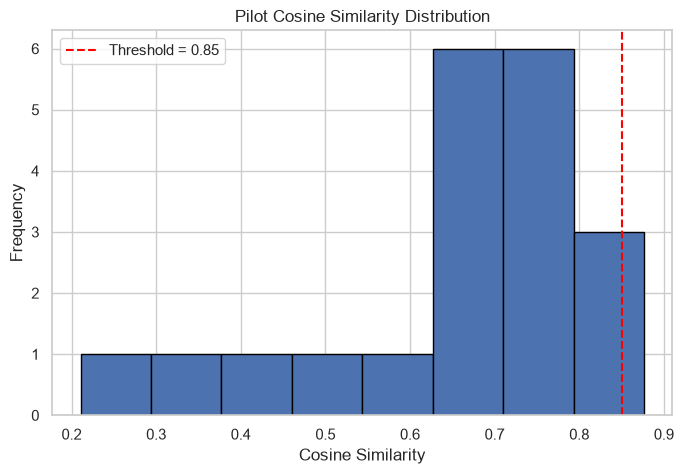

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["cosine_similarity"],
    bins=8,
    edgecolor="black"
)

plt.axvline(
    0.85,
    color="red",
    linestyle="--",
    label="Threshold = 0.85"
)

plt.title("Pilot Cosine Similarity Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("../figures/fig1_distribution.png", dpi=300)

plt.show()

## 7.3 Pilot Analysis Result

### RQ1

The mean cosine similarity between the generated Gherkin scenarios and the manually written scenarios is **0.655**.

Wilcoxon Signed-Rank Test returned **p < 0.05**, therefore **H0 is rejected**.

The generated Gherkin scenarios do **not** achieve the predefined semantic similarity threshold of **0.85**.

---

### RQ2

The executable syntax rate is **100% (20/20)**.

Binomial Exact Test returned **p < 0.05**, therefore **H0 is rejected**.

The generated Gherkin scenarios satisfy the required executable syntax threshold (≥80%).